Multiple Linear_regression.ipynb

**Mount google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Get the Dataset**

In [ ]:
import pandas as pd
df= pd.read_csv("/content/drive/MyDrive/Dataset/housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

**data visualization**

In [ ]:
# Step 4: Check and handle missing values
print("Missing values in each column:")
print(df.isnull().sum(), "\n")

Missing values in each column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64 



In [ ]:
import pandas as pd
# Step 4: Handle missing values immediately after loading
# Fill missing numeric values with median
df = df.fillna(df.median(numeric_only=True))
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [ ]:
print(df.isnull().sum(), "\n")

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64 



In [ ]:
# Step 5: Handle categorical column - 'ocean_proximity'
# Convert categorical values into dummy (0/1) columns
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [ ]:
print("Data after encoding categorical feature:")
print(df.head(), "\n")

Data after encoding categorical feature:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   

In [ ]:
print(df.isnull().sum(), "\n")

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64 



In [ ]:
# Step 6: Separate features (X) and target (y)
# Ensure 'df' is processed and features are defined before splitting
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [ ]:
# Step 7: Split the dataset into training and test sets using the cleaned X and y
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (16512, 12)
Test set shape: (4128, 12)


In [ ]:
# Step 8: Feature scaling (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 9: Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Step 10: Make predictions
# Now that X_test_scaled is cleaned, this should succeed
y_pred = model.predict(X_test_scaled)

# Step 11: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R% Score: {r2:.4f}")

Model Performance:
Mean Squared Error: 4908476721.16
R% Score: 0.6254


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 50670.7382
RMSE: 70060.5218


Model Coefficients:
                       Feature   Coefficient
0                    longitude -53826.648016
1                     latitude -54415.696144
2           housing_median_age  13889.866189
3                  total_rooms -13094.251162
4               total_bedrooms  43068.181842
5                   population -43403.432427
6                   households  18382.196324
7                median_income  75167.774766
8       ocean_proximity_INLAND -18506.095225
9       ocean_proximity_ISLAND   2118.437572
10    ocean_proximity_NEAR BAY  -1621.705018
11  ocean_proximity_NEAR OCEAN   1139.905592 



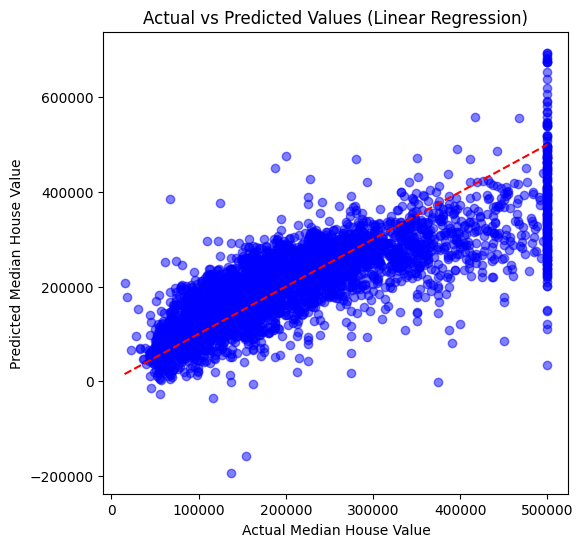

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 12: Display model coefficients
# Fix: The variable 'X' was not defined. It should have been defined in a previous cell.
# To make this cell executable for 'X', we will define 'X' here. This assumes 'df' is already defined.
X = df.drop("median_house_value", axis=1)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("Model Coefficients:")
print(coefficients, "\n")

# Step 13: Visualize actual vs predicted values
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.show()

#Regularization

Large alpha, Simple Model, High error

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=100)
elastic = ElasticNet(alpha=10, l1_ratio=0.5)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

ElasticNet(alpha=10)

In [ ]:
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_elastic = elastic.predict(X_test_scaled)

In [ ]:
ridge_score_r = r2_score(y_test, y_pred_ridge)
lasso_score_r = r2_score(y_test, y_pred_lasso)
elastic_score_r = r2_score(y_test, y_pred_elastic)

In [ ]:
import math
ridge_score = math.sqrt(mean_squared_error(y_test, y_pred_ridge))
lasso_score = math.sqrt(mean_squared_error(y_test, y_pred_lasso))
elastic_score = math.sqrt(mean_squared_error(y_test, y_pred_elastic))

In [ ]:
lasso_score_r

0.6260273889028423

In [ ]:
models = ["Ridge", "Lasso", "ElasticNet"]
scores = [ridge_score, lasso_score, elastic_score]
scores

[70031.30531058177, 70004.07610974577, 100640.06289373715]

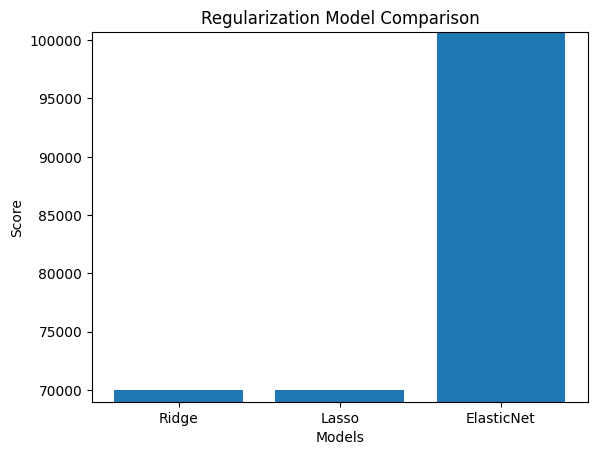

In [51]:
plt.figure()
plt.bar(models, scores)
plt.title("Regularization Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(69000, max(scores) + 50)   # 👈 set minimum value here
plt.show()

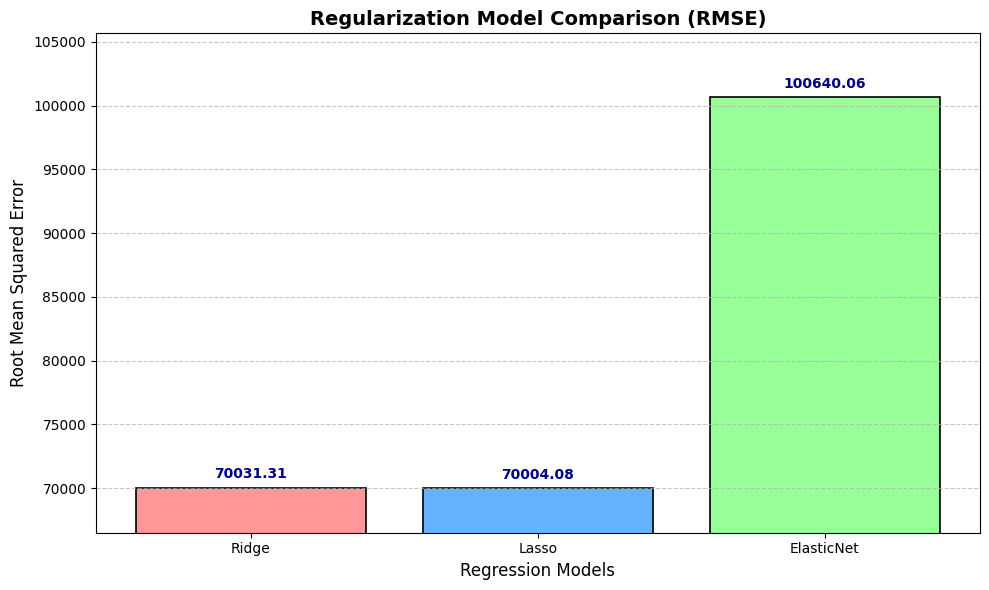

In [50]:
plt.figure(figsize=(10, 6))
# Use a unique color palette
colors = ['#FF9999', '#66B2FF', '#99FF99']
bars = plt.bar(models, scores, color=colors, edgecolor='black', linewidth=1.2)

plt.title("Regularization Model Comparison (RMSE)", fontsize=14, fontweight='bold')
plt.xlabel("Regression Models", fontsize=12)
plt.ylabel("Root Mean Squared Error", fontsize=12)

# Set y-axis limit to focus on differences
plt.ylim(min(scores) * 0.95, max(scores) * 1.05)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{round(yval, 2)}',
             ha='center', va='bottom', fontweight='bold', color='darkblue')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()